In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.neural_network import MLPClassifier

from sklearn.model_selection import GridSearchCV, train_test_split

import time

In [2]:
df_raw = pd.read_csv('Covid Data.csv')
print(df_raw.shape)
df_raw.head()

(1048575, 21)


,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,DATE_DIED,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,...,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,ICU
0,2,1,1,1,03/05/2020,97,1,65,2,2,...,2,2,1,2,2,2,2,2,3,97
1,2,1,2,1,03/06/2020,97,1,72,97,2,...,2,2,1,2,2,1,1,2,5,97
2,2,1,2,2,09/06/2020,1,2,55,97,1,...,2,2,2,2,2,2,2,2,3,2
3,2,1,1,1,12/06/2020,97,2,53,2,2,...,2,2,2,2,2,2,2,2,7,97
4,2,1,2,1,21/06/2020,97,2,68,97,1,...,2,2,1,2,2,2,2,2,3,97


In [3]:
# Replace placeholder missing values with nulls
default_missing_values = [97,98,99]
df_raw.replace(default_missing_values, np.nan, inplace=True)

missingness = df_raw.isnull().sum()/df_raw.shape[0]
missingness[missingness > 0]

INTUBED           0.816221
PNEUMONIA         0.015262
AGE               0.000329
PREGNANT          0.502840
DIABETES          0.003183
COPD              0.002864
ASTHMA            0.002841
INMSUPR           0.003246
HIPERTENSION      0.002960
OTHER_DISEASE     0.004811
CARDIOVASCULAR    0.002934
OBESITY           0.002892
RENAL_CHRONIC     0.002867
TOBACCO           0.003071
ICU               0.816377
dtype: float64

In [4]:
# One-hot encoding patients that died
df_raw['DEATH'] = df_raw.apply(lambda x: 0 if x['DATE_DIED']=='9999-99-99' else 1, axis=1)

In [5]:
df_data = df_raw.drop(columns=['INTUBED','ICU','PREGNANT', 'DATE_DIED'])

# Dropping data points that make up fewer than 5% of total dataset
threshold = 0.05
drop_na_cols = []
for col in missingness.index:
    if missingness[col] < threshold and missingness[col] > 0:
        drop_na_cols.append(col)

df_data.dropna(subset=drop_na_cols, inplace=True)

print(df_data.shape)
df_data.head()

(1024829, 18)


,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,PNEUMONIA,AGE,DIABETES,COPD,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,DEATH
0,2,1,1,1,1.0,65.0,2.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,3,1
1,2,1,2,1,1.0,72.0,2.0,2.0,2.0,2.0,1.0,2.0,2.0,1.0,1.0,2.0,5,1
2,2,1,2,2,2.0,55.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,3,1
3,2,1,1,1,2.0,53.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,7,1
4,2,1,2,1,2.0,68.0,1.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,3,1


In [6]:
percent_na = 1- df_data.shape[0]/df_raw.shape[0]
print(f'We have excluded {np.format_float_positional(percent_na*100, precision=2)}% of data due to null values')

We have excluded 2.26% of data due to null values


In [7]:
# Change values from 1-2 to 0-1 for one-hot encoding
for col in df_data.columns:
    if df_data[col].max() == 2 and df_data[col].min() == 1:
        print(col)
        df_data[col] = df_data[col]-1

df_data.head()

USMER
SEX
PATIENT_TYPE
PNEUMONIA
DIABETES
COPD
ASTHMA
INMSUPR
HIPERTENSION
OTHER_DISEASE
CARDIOVASCULAR
OBESITY
RENAL_CHRONIC
TOBACCO


,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,PNEUMONIA,AGE,DIABETES,COPD,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,DEATH
0,1,1,0,0,0.0,65.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,3,1
1,1,1,1,0,0.0,72.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,5,1
2,1,1,1,1,1.0,55.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,3,1
3,1,1,0,0,1.0,53.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,7,1
4,1,1,1,0,1.0,68.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,3,1


In [8]:
col_uniques = {}
for col in df_data.columns:
    col_uniques[col] = len(df_data[col].unique())

unique_val_count = pd.Series(col_uniques).sort_values()
unique_val_count

USMER                     2
TOBACCO                   2
RENAL_CHRONIC             2
OBESITY                   2
CARDIOVASCULAR            2
OTHER_DISEASE             2
HIPERTENSION              2
INMSUPR                   2
ASTHMA                    2
COPD                      2
DIABETES                  2
PNEUMONIA                 2
PATIENT_TYPE              2
SEX                       2
DEATH                     2
CLASIFFICATION_FINAL      7
MEDICAL_UNIT             13
AGE                     118
dtype: int64

In [9]:
# Putting non-one hot encoded features into a standard scaler
cols_to_scale = []
for col in unique_val_count.index:
    if unique_val_count[col] > 2 and col != 'CLASIFFICATION_FINAL':
        cols_to_scale.append(col)

print(cols_to_scale)

['MEDICAL_UNIT', 'AGE']


In [31]:
# creating X and y
x = df_data.loc[:, df_data.columns != 'DEATH']#.drop(columns='DEATH', inplace=True)
#y = df_data['CLASIFFICATION_FINAL']
y = df_data['DEATH']

In [32]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.25, shuffle=True)

In [54]:
# setting up transformers
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline, Pipeline

In [12]:
def processing_transformer(cols_to_scale):
    prep_transformer = ColumnTransformer(transformers=[('standardscaler', StandardScaler(), cols_to_scale)]
                                                     ,remainder='passthrough')
    return prep_transformer

In [57]:
%%time
data_transformer = processing_transformer(cols_to_scale)
#mlp_clf = make_pipeline(data_transformer, MLPClassifier())
#mlp_clf = make_pipeline(data_transformer, MLPClassifier(hidden_layer_sizes=(300,3), activation = 'relu', solver='adam', max_iter=500, early_stopping=True))

mlp = MLPClassifier(max_iter=500, early_stopping=True)
mlp_pipe = Pipeline([('preprocess', data_transformer), ('mlp', mlp)])
mlp_params = {'mlp__hidden_layer_sizes' : ((200,1), (200,2), (300,2)),
                'mlp__activation' : ('relu', 'logistic'),
                'mlp__solver' : ('adam', 'lbfgs', 'sgd')}

# Leveraging GridSearchCV to optimise hyper-parameters on the training data
mlp_clf = GridSearchCV(mlp_pipe, param_grid=mlp_params)

CPU times: total: 0 ns
Wall time: 0 ns


In [58]:
%%time
mlp_model = mlp_clf.fit(X_train,y_train)

C:\Users\wesle\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
C:\Users\wesle\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
C:\Users\wesle\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptr

CPU times: total: 1d 3h 42min 27s
Wall time: 9h 48min 3s


In [59]:
y_pred = mlp_model.predict(X_test)

In [45]:
from sklearn.metrics import precision_recall_fscore_support, balanced_accuracy_score, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score

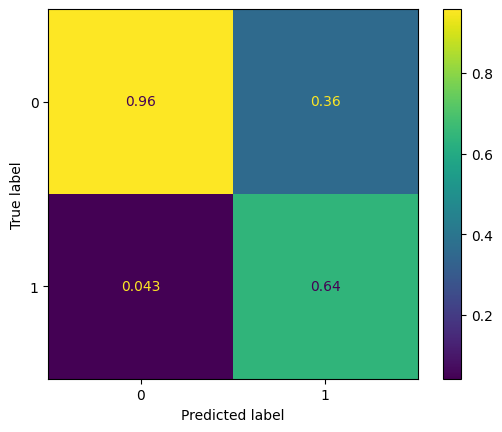

In [60]:
cm = confusion_matrix(y_test, y_pred, normalize='pred')
conf_matrix = ConfusionMatrixDisplay(confusion_matrix=cm)
conf_matrix.plot()
plt.show()

In [61]:
y_test.value_counts()

DEATH
0    237412
1     18796
Name: count, dtype: int64

In [51]:
df_raw['CLASIFFICATION_FINAL'].value_counts()

CLASIFFICATION_FINAL
7    499250
3    381527
6    128133
5     26091
1      8601
4      3122
2      1851
Name: count, dtype: int64